<a href="https://colab.research.google.com/github/saimanhamal/ok/blob/main/tut4(tasks).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Remove old dataset (prevents overwrite issue)
!rm -rf /content/dataset

# Extract fresh dataset
!unzip -q "/content/drive/MyDrive/Colab Notebooks/Copy of devnagari digit.zip" -d /content/dataset

print("✅ Dataset extracted!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset extracted!


In [3]:
!ls /content/dataset


DevanagariHandwrittenDigitDataset


In [4]:
train_dir = "/content/dataset/DevanagariHandwrittenDigitDataset/Train"
test_dir  = "/content/dataset/DevanagariHandwrittenDigitDataset/Test"

img_height, img_width = 28, 28

In [5]:
def load_images_from_folder(folder):
    images, labels = [], []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                img = Image.open(img_path).convert("L")  # grayscale
                img = img.resize((img_width, img_height))
                img = np.array(img) / 255.0

                images.append(img)
                labels.append(class_map[class_name])

            except Exception as e:
                print(f"Skipped {filename}: {e}")

    return np.array(images), np.array(labels)

In [9]:
x_train, y_train = load_images_from_folder(train_dir)
x_test,  y_test  = load_images_from_folder(test_dir)

print("Train:", x_train.shape)
print("Test: ", x_test.shape)


Train: (17000, 28, 28)
Test:  (3000, 28, 28)


In [10]:
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

y_train_ohe = to_categorical(y_train, num_classes=10)
y_test_ohe  = to_categorical(y_test,  num_classes=10)

print("Processed:")
print("Train:", x_train.shape, y_train_ohe.shape)
print("Test: ", x_test.shape,  y_test_ohe.shape)

Processed:
Train: (17000, 784) (17000, 10)
Test:  (3000, 784) (3000, 10)


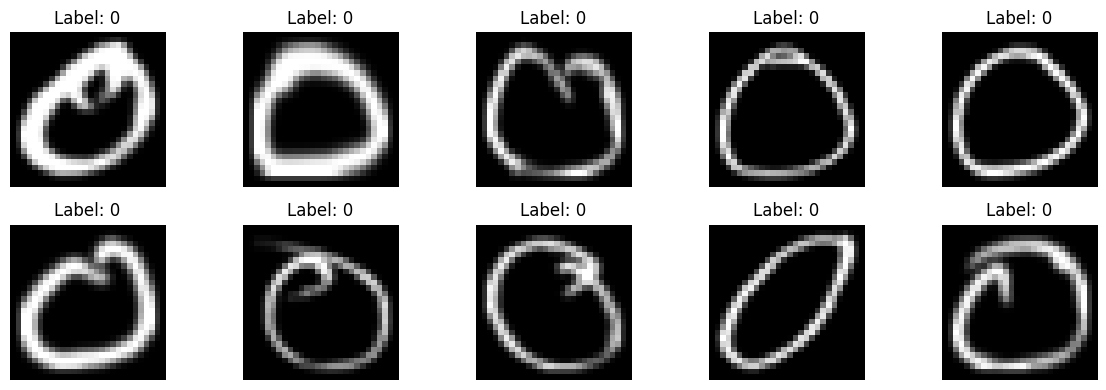

In [11]:
plt.figure(figsize=(12, 4))
for i in range(min(10, len(x_train))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3)
]

history = model.fit(
    x_train,
    y_train_ohe,
    batch_size=128,
    epochs=10,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8627 - loss: 0.4739 - val_accuracy: 0.0000e+00 - val_loss: 11.4100
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9640 - loss: 0.1308 - val_accuracy: 0.0000e+00 - val_loss: 12.6389
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9768 - loss: 0.0855 - val_accuracy: 0.0000e+00 - val_loss: 13.4054
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9834 - loss: 0.0588 - val_accuracy: 0.0000e+00 - val_loss: 14.1751


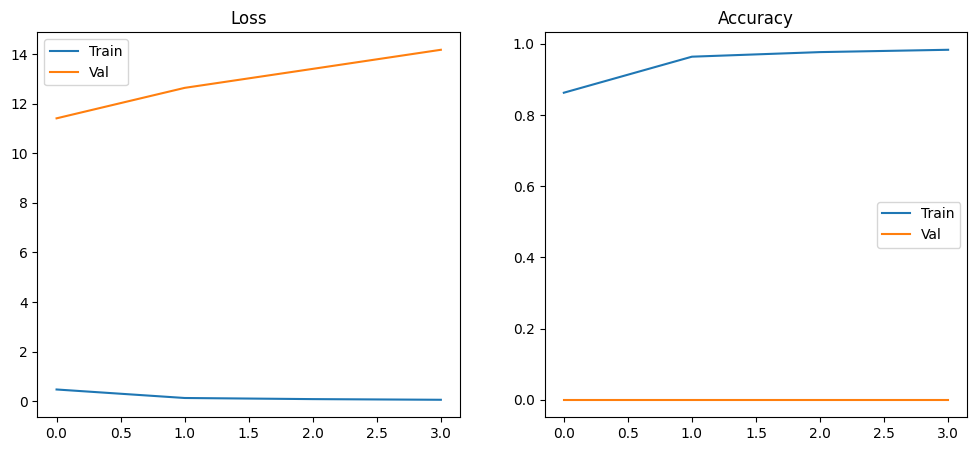

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Val"])

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Val"])

plt.show()


In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test_ohe)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7813 - loss: 2.8953
Test Accuracy: 0.781333327293396


In [16]:
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [17]:
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [18]:
model.save("devnagari_model.h5")
print("✅ Model saved!")

loaded_model = tf.keras.models.load_model("devnagari_model.h5")
loss, acc = loaded_model.evaluate(x_test, y_test_ohe)

print("Loaded Model Accuracy:", acc)

✅ Model saved!
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7813 - loss: 2.8953
Loaded Model Accuracy: 0.781333327293396
